## План выполнения проекта

### Как решаем задачу

1. Загружаем датасет Minecraft в формате COCO и распаковываем в datasets/minecraft/
2. Проводим EDA: проверяем структуру аннотаций, распределение классов, выявляем дисбаланс
3. Настраиваем конфигурацию FCOS: 12 эпох, размер 512, batch_size=2, fp16
4. Настраиваем YOLO: 30-50 эпох, аугментации (mosaic, mixup, copy_paste)
5. Обучаем FCOS и YOLO на train, валидируем на val
6. Выполняем инференс на тестовых изображениях и видео
7. Сравниваем модели по mAP, mAP50, FPS
8. Формируем отчет и сохраняем артефакты

### Из чего состоит система

- **MMDetection** (FCOS R50) — двухстадийный детектор с якорными точками
- **Ultralytics YOLOv8s** — однопроходной детектор в реальном времени
- **Датасет** — 17 классов мобов Minecraft в COCO формате
- **Артефакты** — веса, логи, метрики, видео, изображения с детекциями

In [ ]:
import os
from google.colab import drive
import zipfile

if not os.path.exists('/content/mmdetection'):
    !git clone https://github.com/open-mmlab/mmdetection.git /content/mmdetection


%cd /content/mmdetection

!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.0.1 torchvision==0.15.2
!pip install mmcv==2.1.0 -f https://download.openmmlab.com/mmcv/dist/cu118/torch2.0/index.html

!pip install mmengine==0.10.7
!pip install -e .

drive.mount('/content/drive')

if not os.path.exists('/content/mmdetection/datasets'):
    with zipfile.ZipFile('/content/drive/MyDrive/minecraft_project/minecraft_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/mmdetection')

os.makedirs('/content/mmdetection/datasets/minecraft/annotations', exist_ok=True)
if os.path.exists('/content/mmdetection/datasets/minecraft/train/annotations.json'):
    !mv /content/mmdetection/datasets/minecraft/train/annotations.json /content/mmdetection/datasets/minecraft/annotations/

!mkdir -p artifacts checkpoints artifacts/inference artifacts/videos artifacts/yolo artifacts/metrics configs/fcos
print("Готово")

Cloning into '/content/mmdetection'...
remote: Enumerating objects: 38023, done.
remote: Total 38023 (delta 0), reused 0 (delta 0), pack-reused 38023 (from 1)
Receiving objects: 100% (38023/38023), 63.18 MiB | 15.17 MiB/s, done.
Resolving deltas: 100% (26221/26221), done.
/content/mmdetection
Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 144.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 133

In [ ]:
%cd /content/mmdetection
!python3.11 -m pip install ultralytics
!pip install numpy==1.23.5


/content/mmdetection
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 80.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.24 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
albumentations 2.0.8 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
bigframes 2.10.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
blosc2 3.5.1 requires numpy>=1.26, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
db-dtypes 1.4.3 requires numpy>=1.24.0, but you have numpy

In [ ]:
%%writefile /content/mmdetection/configs/fcos/fcos_minecraft.py
_base_ = 'fcos_r50-caffe_fpn_gn-head_1x_coco.py'

classes = ('bee','chicken','cow','creeper','enderman','fox','frog','ghast',
           'goat','llama','pig','sheep','skeleton','spider','turtle','wolf','zombie')

model = dict(
    backbone=dict(
        init_cfg=dict(type='Pretrained', checkpoint='open-mmlab://detectron2/resnet50_caffe')
    ),
    bbox_head=dict(num_classes=len(classes)),
)

data_root = 'datasets/minecraft/'


metainfo = dict(classes=classes)

# Даталодеры
train_dataloader = dict(
    batch_size=2,
    num_workers=2,
    dataset=dict(
        type='CocoDataset',
        metainfo=metainfo,
        data_root=data_root,
        ann_file='annotations/annotations.json',
        data_prefix=dict(img='train/'),
        pipeline=[
            dict(type='LoadImageFromFile'),
            dict(type='LoadAnnotations', with_bbox=True),
            dict(type='Resize', scale=(512, 512), keep_ratio=True),
            dict(type='RandomFlip', prob=0.5),
            dict(type='PackDetInputs'),
        ]),
    sampler=dict(type='DefaultSampler', shuffle=True),
)

val_dataloader = dict(
    batch_size=1,
    num_workers=2,
    dataset=dict(
        type='CocoDataset',
        metainfo=metainfo,
        data_root=data_root,
        ann_file='valid/annotations.json',
        data_prefix=dict(img='valid/'),
        pipeline=[
            dict(type='LoadImageFromFile'),
            dict(type='Resize', scale=(512, 512), keep_ratio=True),
            dict(type='PackDetInputs'),
        ]),
    sampler=dict(type='DefaultSampler', shuffle=False),
)

test_dataloader = val_dataloader

# Evaluator
val_evaluator = dict(
    type='CocoMetric',
    ann_file=data_root + 'valid/annotations.json',
    metric='bbox',
    format_only=False,
)

test_evaluator = val_evaluator

train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=12, val_interval=1)
val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

optim_wrapper = dict(
    optimizer=dict(type='SGD', lr=0.01, momentum=0.9, weight_decay=0.0001),
    clip_grad=dict(max_norm=35, norm_type=2),
)

param_scheduler = [
    dict(type='LinearLR', start_factor=0.333, by_epoch=False, begin=0, end=500),
    dict(type='MultiStepLR', by_epoch=True, milestones=[8, 11], gamma=0.1),
]

visualizer = dict(
    type='DetLocalVisualizer',
    vis_backends=[dict(type='LocalVisBackend')],
    name='visualizer',
)

default_hooks = dict(
    checkpoint=dict(type='CheckpointHook', interval=1, save_best='coco/bbox_mAP', rule='greater')
)

work_dir = '/content/drive/MyDrive/minecraft_project/artifacts/fcos'

Writing /content/mmdetection/configs/fcos/fcos_minecraft.py


In [ ]:
# ============================================
# Создаем YOLO конфиг
# ============================================
%%writefile /content/mmdetection/datasets/minecraft/data.yaml
path: /content/mmdetection/datasets/minecraft
train: train
val: valid
test: test

nc: 17
names: ['bee','chicken','cow','creeper','enderman','fox','frog','ghast',
         'goat','llama','pig','sheep','skeleton','spider','turtle','wolf','zombie']

Writing /content/mmdetection/datasets/minecraft/data.yaml


/content/mmdetection
Структура датасета:
total 324
drwxr-xr-x 6 root root   4096 May  7 18:10 .
drwxr-xr-x 3 root root   4096 May  7 18:09 ..
drwxr-xr-x 2 root root   4096 May  7 18:09 annotations
-rw-r--r-- 1 root root    246 May  7 18:10 data.yaml
-rw-r--r-- 1 root root  10244 May  7 18:09 .DS_Store
drwxr-xr-x 2 root root  20480 May  7 18:09 test
drwxr-xr-x 2 root root 237568 May  7 18:09 train
drwxr-xr-x 2 root root  45056 May  7 18:09 valid

Images: 2307
Annotations: 4029
images: OK
annotations: OK
categories: OK

Всего изображений: 2307
Изображений с аннотациями: 2307
Совпадение: YES

Min samples: 4, Max samples: 884
Max/min ratio: 221.0:1
Дисбаланс: STRONG


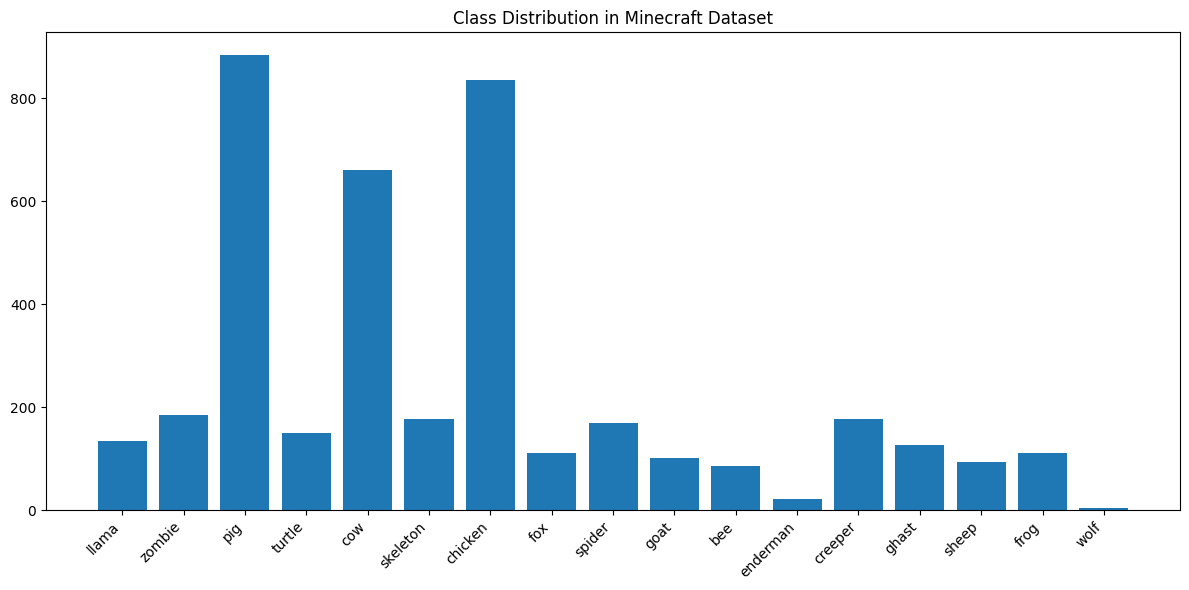

Cannot load: datasets/minecraft/test/2023-03-28_05_03_37_png.rf.12bb368c8a9cb5ab3b17dc43fae07f4d.jpg


In [ ]:
# ============================================
# Проверяем датасет
# ============================================
%cd /content/mmdetection

import json
import matplotlib.pyplot as plt
from collections import Counter
import os
import cv2
import random

print("Структура датасета:")
!ls -la datasets/minecraft/

with open('datasets/minecraft/annotations/annotations.json') as f:
    coco_data = json.load(f)

print(f"\nImages: {len(coco_data['images'])}")
print(f"Annotations: {len(coco_data['annotations'])}")

# проверка структуры JSON
required_keys = ['images', 'annotations', 'categories']
for key in required_keys:
    if key in coco_data:
        print(f"{key}: OK")
    else:
        print(f"{key}: MISSING")

# проверка совпадения количества
img_ids_with_ann = set([ann['image_id'] for ann in coco_data['annotations']])
total_images = len(coco_data['images'])
images_with_ann = len(img_ids_with_ann)
print(f"\nВсего изображений: {total_images}")
print(f"Изображений с аннотациями: {images_with_ann}")
if total_images == images_with_ann:
    print("Совпадение: YES")
else:
    print(f"Совпадение: NO ({total_images - images_with_ann} без аннотаций)")

# распределение классов
class_counts = Counter()
for ann in coco_data['annotations']:
    class_counts[ann['category_id']] += 1

categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

# анализ дисбаланса
min_count = min(class_counts.values())
max_count = max(class_counts.values())
print(f"\nMin samples: {min_count}, Max samples: {max_count}")
print(f"Max/min ratio: {max_count/min_count:.1f}:1")
if max_count/min_count > 10:
    print("Дисбаланс: STRONG")
else:
    print("Дисбаланс: MODERATE")

# визуализация распределения
plt.figure(figsize=(12, 6))
classes_names = [categories[i] for i in class_counts.keys()]
counts = list(class_counts.values())
plt.bar(classes_names, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution in Minecraft Dataset')
plt.tight_layout()
plt.savefig('artifacts/class_distribution.png')
plt.show()

# визуализация тестового примера с bbox
test_img_id = random.choice([img['id'] for img in coco_data['images']])
test_img = next(img for img in coco_data['images'] if img['id'] == test_img_id)
img_path = f"datasets/minecraft/test/{test_img['file_name']}"

test_anns = [ann for ann in coco_data['annotations'] if ann['image_id'] == test_img_id]

img = cv2.imread(img_path)
if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for ann in test_anns:
        x, y, w, h = [int(v) for v in ann['bbox']]
        cat_name = categories[ann['category_id']]
        cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(img, cat_name, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Test: {test_img['file_name']}")
    os.makedirs('artifacts/inference', exist_ok=True)
    plt.savefig('artifacts/inference/test_sample_bbox.jpg', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: artifacts/inference/test_sample_bbox.jpg")
else:
    print(f"Cannot load: {img_path}")

/content/mmdetection


Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FCOS checkpoint copied
Selected: datasets/minecraft/test/creeper-60-_png.rf.12403f46c516d763ca5c42fae7e5ac90.jpg
Loads checkpoint by local backend from path: checkpoints/fcos_pretrained.pth


/usr/local/lib/python3.11/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


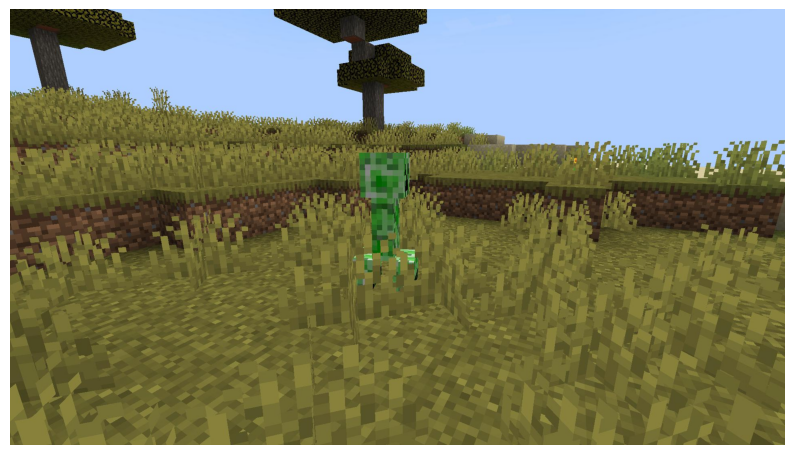

Saved: /content/drive/MyDrive/minecraft_project/artifacts/inference/fcos_pretrained.jpg

image 1/1 /content/mmdetection/datasets/minecraft/test/creeper-60-_png.rf.12403f46c516d763ca5c42fae7e5ac90.jpg: 384x640 (no detections), 62.4ms
Speed: 9.4ms preprocess, 62.4ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Saved: /content/drive/MyDrive/minecraft_project/artifacts/inference/yolo_pretrained.jpg


In [ ]:
# ============================================
# Тест предобученных моделей
# ============================================
%cd /content/mmdetection

import os
import random
import shutil
from mmdet.apis import init_detector, inference_detector
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import glob

# копирование чекпоинта предобученной FCOS
os.makedirs('checkpoints', exist_ok=True)
src = '/content/drive/MyDrive/minecraft_project/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth'
dst = 'checkpoints/fcos_pretrained.pth'
if os.path.exists(src):
    shutil.copy2(src, dst)
    print("FCOS checkpoint copied")

# выбираем рандомное изображение из test
test_images = glob.glob('datasets/minecraft/test/*.jpg')
if len(test_images) > 0:
    img_path = random.choice(test_images)
    print(f"Selected: {img_path}")

# тест предобученной FCOS
config_pretrained = 'configs/fcos/fcos_r50-caffe_fpn_gn-head_1x_coco.py'
if os.path.exists(config_pretrained) and os.path.exists(img_path):
    model_fcos_pretrained = init_detector(config_pretrained, dst, device='cuda')
    result = inference_detector(model_fcos_pretrained, img_path)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if hasattr(result, 'pred_instances'):
        bboxes = result.pred_instances.bboxes.cpu().numpy()
        scores = result.pred_instances.scores.cpu().numpy()
        for bbox, score in zip(bboxes, scores):
            if score > 0.3:
                bbox = bbox.astype(int)
                cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0,255,0), 2)
    else:
        for i, detections in enumerate(result):
            for det in detections:
                if det[4] > 0.3:
                    bbox = det[:4].astype(int)
                    cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0,255,0), 2)

    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.axis('off')
    os.makedirs('/content/drive/MyDrive/minecraft_project/artifacts/inference', exist_ok=True)
    plt.savefig('/content/drive/MyDrive/minecraft_project/artifacts/inference/fcos_pretrained.jpg', dpi=150)
    plt.show()
    print("Saved: /content/drive/MyDrive/minecraft_project/artifacts/inference/fcos_pretrained.jpg")

# тест предобученной YOLOv8s
if os.path.exists(img_path):
    model_yolo_pretrained = YOLO('yolov8s.pt')
    results = model_yolo_pretrained(img_path)
    results[0].save('/content/drive/MyDrive/minecraft_project/artifacts/inference/yolo_pretrained.jpg')
    print("Saved: /content/drive/MyDrive/minecraft_project/artifacts/inference/yolo_pretrained.jpg")

In [ ]:
# ============================================
# Обучение FCOS
# ============================================
%cd /content/mmdetection

!python tools/train.py \
    configs/fcos/fcos_minecraft.py \
    --work-dir /content/drive/MyDrive/minecraft_project/artifacts/fcos \
    --auto-scale-lr

/content/mmdetection
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1
05/07 16:34:05 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1604198529
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage:

/content/mmdetection


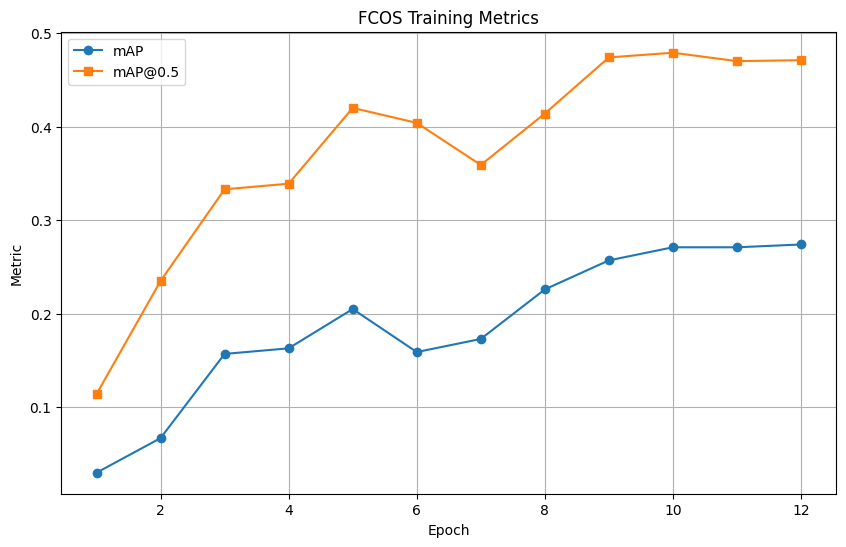

Saved: /content/drive/MyDrive/minecraft_project/artifacts/metrics/fcos_metrics.png


In [ ]:
# ============================================
# Визуализация метрик FCOS из scalars.json
# ============================================
%cd /content/mmdetection

import json
import matplotlib.pyplot as plt
import glob
import os

log_files = glob.glob('/content/drive/MyDrive/minecraft_project/artifacts/fcos/*/vis_data/scalars.json')
if len(log_files) > 0:
    log_file = log_files[0]
    data = []
    with open(log_file, 'r') as f:
        for line in f:
            try:
                record = json.loads(line)
                if 'coco/bbox_mAP' in record:
                    data.append(record)
            except:
                pass

    if len(data) > 0:
        epochs = [d['step'] for d in data]
        map50 = [d['coco/bbox_mAP_50'] for d in data]
        map = [d['coco/bbox_mAP'] for d in data]

        plt.figure(figsize=(10, 6))
        plt.plot(epochs, map, label='mAP', marker='o')
        plt.plot(epochs, map50, label='mAP@0.5', marker='s')
        plt.xlabel('Epoch')
        plt.ylabel('Metric')
        plt.title('FCOS Training Metrics')
        plt.legend()
        plt.grid(True)
        os.makedirs('/content/drive/MyDrive/minecraft_project/artifacts/metrics', exist_ok=True)
        plt.savefig('/content/drive/MyDrive/minecraft_project/artifacts/metrics/fcos_metrics.png', dpi=150)
        plt.show()
        print("Saved: /content/drive/MyDrive/minecraft_project/artifacts/metrics/fcos_metrics.png")
    else:
        print("No metric data found in log file")
else:
    print("No scalars.json found in artifacts/fcos/")

In [ ]:
# ============================================
# Конвертация в YOLO формат
# ============================================

%cd /content/mmdetection

import json
import os
from tqdm import tqdm

def coco_to_yolo(coco_json_path, output_labels_dir, images_dir):
    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    os.makedirs(output_labels_dir, exist_ok=True)

    img_id_to_file = {}
    img_id_to_size = {}
    for img in coco['images']:
        img_id_to_file[img['id']] = img['file_name']
        img_id_to_size[img['id']] = (img['width'], img['height'])

    anns_by_img = {}
    for ann in coco['annotations']:
        img_id = ann['image_id']
        if img_id not in anns_by_img:
            anns_by_img[img_id] = []
        anns_by_img[img_id].append(ann)

    for img_id, anns in tqdm(anns_by_img.items()):
        img_name = img_id_to_file[img_id]
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(output_labels_dir, txt_name)

        img_w, img_h = img_id_to_size[img_id]

        with open(txt_path, 'w') as f:
            for ann in anns:
                cat_id = ann['category_id']
                class_id = cat_id - 1

                x, y, w, h = ann['bbox']
                x_center = (x + w/2) / img_w
                y_center = (y + h/2) / img_h
                w_norm = w / img_w
                h_norm = h / img_h

                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

print("Конвертация train...")
coco_to_yolo('datasets/minecraft/annotations/annotations.json',
             'datasets/minecraft/train',
             'datasets/minecraft/train')

print("Конвертация valid...")
coco_to_yolo('datasets/minecraft/valid/annotations.json',
             'datasets/minecraft/valid',
             'datasets/minecraft/valid')

print("Конвертация test...")
coco_to_yolo('datasets/minecraft/test/annotations.json',
             'datasets/minecraft/test',
             'datasets/minecraft/test')

/content/mmdetection
Конвертация train...


100%|██████████| 2307/2307 [00:00<00:00, 13808.18it/s]


Конвертация valid...


100%|██████████| 422/422 [00:00<00:00, 10479.68it/s]


Конвертация test...


100%|██████████| 155/155 [00:00<00:00, 10403.87it/s]


In [ ]:
# ============================================
# Проверка перед обучением
# ============================================
%cd /content/mmdetection

print("=== ПРОВЕРКА СТРУКТУРЫ ===\n")

# 1. Существуют ли папки для labels
for split in ['train', 'valid', 'test']:
    labels_path = f'datasets/minecraft/{split}'
    images_path = f'datasets/minecraft/{split}'
    print(f"{split.upper()}:")
    print(f"  Изображения: {len(os.listdir(images_path)) if os.path.exists(images_path) else 'НЕТ ПАПКИ'} файлов (только .jpg)")
    print(f"  Labels: {len(os.listdir(labels_path)) if os.path.exists(labels_path) else 'НЕТ ПАПКИ'} файлов .txt")
    print()

# 2. Сравнить количество .jpg и .txt для каждого сплита
import glob
for split in ['train', 'valid', 'test']:
    images = glob.glob(f'datasets/minecraft/{split}/*.jpg')
    txts = glob.glob(f'datasets/minecraft/{split}/*.txt')
    print(f"{split}: {len(images)} изображений, {len(txts)} .txt файлов")
    if len(images) == len(txts):
        print(f"OK - количество совпадает")
    else:
        print(f"НЕ СОВПАДАЕТ")

# 3. Проверить формат первых 5 .txt файлов
print("\n=== ПРОВЕРКА ФОРМАТА .txt ===\n")
for split in ['train', 'valid', 'test']:
    txt_files = glob.glob(f'datasets/minecraft/{split}/*.txt')
    if txt_files:
        sample = txt_files[0]
        print(f"{split} пример: {sample}")
        with open(sample, 'r') as f:
            lines = f.readlines()[:3]
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = parts[0]
                    coords = parts[1:]
                    print(f"  class_id: {class_id} (0-16), координаты: {' '.join(coords)}")
                else:
                    print(f"НЕПРАВИЛЬНЫЙ ФОРМАТ: {line.strip()}")
        print()

# 4. Проверить data.yaml
print("=== data.yaml ===\n")
with open('datasets/minecraft/data.yaml', 'r') as f:
    print(f.read())

# 5. Проверить что test прописан
print("=== ПРОВЕРКА ТЕСТА ===\n")
test_path = 'datasets/minecraft/test'
if os.path.exists(test_path):
    print(f"test папка существует")
    print(f"Изображений: {len(glob.glob(f'{test_path}/*.jpg'))}")
    print(f".txt файлов: {len(glob.glob(f'{test_path}/*.txt'))}")
else:
    print(f"test папка НЕ существует")

/content/mmdetection
=== ПРОВЕРКА СТРУКТУРЫ ===

TRAIN:
  Изображения: 4615 файлов (только .jpg)
  Labels: 4615 файлов .txt

VALID:
  Изображения: 846 файлов (только .jpg)
  Labels: 846 файлов .txt

TEST:
  Изображения: 312 файлов (только .jpg)
  Labels: 312 файлов .txt

train: 2307 изображений, 2307 .txt файлов
OK - количество совпадает
valid: 422 изображений, 422 .txt файлов
OK - количество совпадает
test: 155 изображений, 155 .txt файлов
OK - количество совпадает

=== ПРОВЕРКА ФОРМАТА .txt ===

train пример: datasets/minecraft/train/2022-08-19_08-25-07_png.rf.f3ca5451eefe91ac3c30ee1f8e4d49fd.txt
  class_id: 3 (0-16), координаты: 0.651302 0.604640 0.084896 0.413623
  class_id: 3 (0-16), координаты: 0.597396 0.442744 0.013542 0.076012
  class_id: 3 (0-16), координаты: 0.532813 0.427937 0.017708 0.060217

valid пример: datasets/minecraft/valid/enderman-36-_png.rf.21a8233eea7675a36098ce74e9e5a0d3.txt
  class_id: 4 (0-16), координаты: 0.457865 0.440287 0.078229 0.273167

test пример: dat

In [ ]:
# ============================================
# Обучение YOLO
# ============================================

%cd /content/mmdetection

from ultralytics import YOLO

model = YOLO('yolov8s.pt')

model.train(
    data='datasets/minecraft/data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/minecraft_project/artifacts/yolo',
    name='exp_aug',
    mosaic=1.0,
    mixup=0.3,
    copy_paste=0.3,
    degrees=10.0,
    scale=0.7,
    translate=0.2,
    fliplr=0.5,
    flipud=0.1,
    erasing=0.4,
    crop_fraction=0.6
)

/content/mmdetection
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.4.47 🚀 Python-3.11.13 torch-2.0.1+cu117 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/minecraft/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_aug, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4, 10, 11, 12, 13, 15, 16])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7827094f07d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.0460

/content/mmdetection


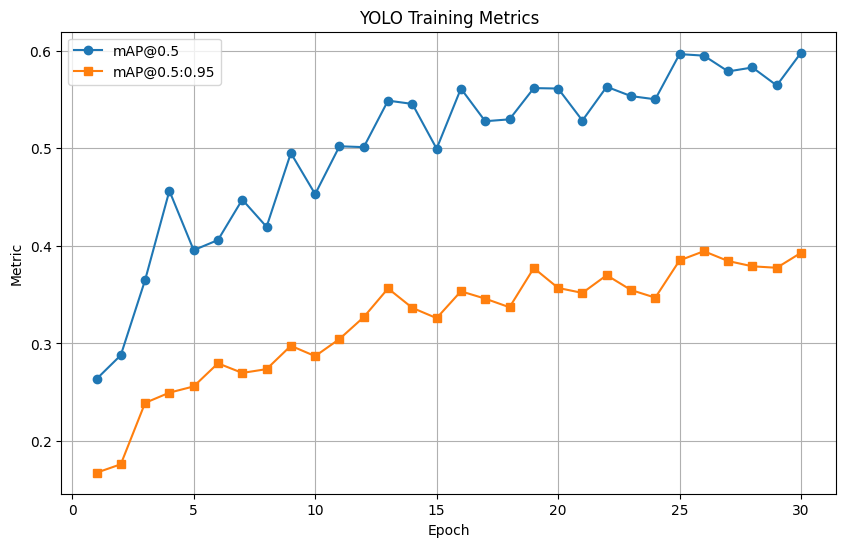

Saved: /content/drive/MyDrive/minecraft_project/artifacts/metrics/yolo_metrics.png


In [ ]:
# ============================================
# Визуализация метрик YOLO из results.csv
# ============================================
%cd /content/mmdetection

import pandas as pd
import matplotlib.pyplot as plt
import glob

csv_files = glob.glob('/content/drive/MyDrive/minecraft_project/artifacts/yolo/exp_aug/results.csv')
if len(csv_files) > 0:
    csv_file = csv_files[0]
    df = pd.read_csv(csv_file)

    plt.figure(figsize=(10, 6))
    if 'metrics/mAP50(B)' in df.columns:
        plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', marker='o')
    if 'metrics/mAP50-95(B)' in df.columns:
        plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', marker='s')

    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.title('YOLO Training Metrics')
    plt.legend()
    plt.grid(True)
    os.makedirs('/content/drive/MyDrive/minecraft_project/artifacts/metrics', exist_ok=True)
    plt.savefig('/content/drive/MyDrive/minecraft_project/artifacts/metrics/yolo_metrics.png', dpi=150)
    plt.show()
    print("Saved: /content/drive/MyDrive/minecraft_project/artifacts/metrics/yolo_metrics.png")
else:
    print("No results.csv found in artifacts/yolo/")

In [ ]:
# ============================================
# Инференс на 5 тестовых изображениях
# ============================================
%cd /content/mmdetection

import glob
import cv2
import matplotlib.pyplot as plt
from mmdet.apis import init_detector, inference_detector
from ultralytics import YOLO
import os

# загрузка обученных моделей
model_fcos = init_detector('configs/fcos/fcos_minecraft.py', '/content/drive/MyDrive/minecraft_project/artifacts/fcos/best_coco_bbox_mAP_epoch_10.pth', device='cuda')
model_yolo = YOLO('/content/drive/MyDrive/minecraft_project/artifacts/yolo/exp_aug/weights/best.pt')

# выбор 5 тестовых изображений
test_images = glob.glob('datasets/minecraft/test/*.jpg')[:5]
print(f"Found {len(test_images)} test images")

# инференс FCOS
os.makedirs('/content/drive/MyDrive/minecraft_project/artifacts/inference/fcos', exist_ok=True)
for i, img_path in enumerate(test_images):
    result = inference_detector(model_fcos, img_path)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if hasattr(result, 'pred_instances'):
        pred_instances = result.pred_instances
        bboxes = pred_instances.bboxes.cpu().numpy()
        scores = pred_instances.scores.cpu().numpy()
        labels = pred_instances.labels.cpu().numpy()

        for bbox, score, label in zip(bboxes, scores, labels):
            if score > 0.5:
                bbox = bbox.astype(int)
                class_name = model_fcos.dataset_meta['classes'][label]
                label_text = f"{class_name}: {score:.2f}"
                cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0,255,0), 2)
                cv2.putText(img, label_text, (bbox[0], bbox[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
    else:
        for class_idx, detections in enumerate(result):
            for det in detections:
                if det[4] > 0.5:
                    bbox = det[:4].astype(int)
                    label = f"{model_fcos.CLASSES[class_idx]}: {det[4]:.2f}"
                    cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0,255,0), 2)
                    cv2.putText(img, label, (bbox[0], bbox[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.axis('off')
    plt.savefig(f'/content/drive/MyDrive/minecraft_project/artifacts/inference/fcos/test_{i}.jpg', dpi=150, bbox_inches='tight')
    plt.close()
print("FCOS: 5 images saved to artifacts/inference/fcos/")

# инференс YOLO
os.makedirs('/content/drive/MyDrive/minecraft_project/artifacts/inference/yolo', exist_ok=True)
for i, img_path in enumerate(test_images):
    results = model_yolo(img_path)
    results[0].save(f'/content/drive/MyDrive/minecraft_project/artifacts/inference/yolo/test_{i}.jpg')
print("YOLO: 5 images saved to artifacts/inference/yolo/")

/content/mmdetection
Loads checkpoint by local backend from path: /content/drive/MyDrive/minecraft_project/artifacts/fcos/best_coco_bbox_mAP_epoch_10.pth
Found 5 test images
FCOS: 5 images saved to artifacts/inference/fcos/

image 1/1 /content/mmdetection/datasets/minecraft/test/Minecraft-1-19-2-2022-11-30-4_44_19_png.rf.ec997a1422c3a0b4e79a5a457f8ed9ee.jpg: 384x640 3 pigs, 12.2ms
Speed: 3.9ms preprocess, 12.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/mmdetection/datasets/minecraft/test/-6-_jpg.rf.7c68f54059fcb0640c83b3b880e261fb.jpg: 416x640 1 pig, 2 sheeps, 16.0ms
Speed: 5.1ms preprocess, 16.0ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 640)

image 1/1 /content/mmdetection/datasets/minecraft/test/-64-_jpg.rf.6f18cb095b92909eaad7861dd95938e7.jpg: 384x640 1 pig, 1 sheep, 13.7ms
Speed: 3.4ms preprocess, 13.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/mmdetection/datasets/minecraft/

In [ ]:
# ============================================
# Инференс FCOS на видео
# ============================================
%cd /content/mmdetection

from mmdet.apis import init_detector, inference_detector
import cv2
from ultralytics import YOLO

# FCOS
model_fcos = init_detector(
    'configs/fcos/fcos_minecraft.py',
    '/content/drive/MyDrive/minecraft_project/artifacts/fcos/best_coco_bbox_mAP_epoch_10.pth',
    device='cuda'
)

# YOLO
model_yolo = YOLO('/content/drive/MyDrive/minecraft_project/artifacts/yolo/exp_aug/weights/best.pt')

# Видео должно лежать в /content/drive/MyDrive/minecraft_project/videos/video.mp4
video_path = '/content/drive/MyDrive/minecraft_project/video.mp4'
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Инференс FCOS
out = cv2.VideoWriter('/content/drive/MyDrive/minecraft_project/artifacts/videos/fcos_inference.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

cap = cv2.VideoCapture(video_path)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    result = inference_detector(model_fcos, frame)
    if hasattr(result, 'pred_instances'):
        pred_instances = result.pred_instances
        bboxes = pred_instances.bboxes.cpu().numpy()
        scores = pred_instances.scores.cpu().numpy()
        labels = pred_instances.labels.cpu().numpy()

        for bbox, score, label in zip(bboxes, scores, labels):
            if score > 0.25:
                bbox = bbox.astype(int)
                class_name = model_fcos.dataset_meta['classes'][label]
                label_text = f"{class_name}: {score:.2f}"
                cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0,255,0), 2)
                cv2.putText(frame, label_text, (bbox[0], bbox[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
    else:
        for i, detections in enumerate(result):
            for det in detections:
                if det[4] > 0.25:
                    bbox = det[:4].astype(int)
                    label = f"{model_fcos.CLASSES[i]}: {det[4]:.2f}"
                    cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0,255,0), 2)
                    cv2.putText(frame, label, (bbox[0], bbox[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
    out.write(frame)
cap.release()
out.release()
print("✅ FCOS video saved")

# Инференс YOLO
out = cv2.VideoWriter('/content/drive/MyDrive/minecraft_project/artifacts/videos/yolo_inference.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

for result in model_yolo.predict(source=video_path, stream=True, save=False, conf=0.25):
    frame = result.orig_img
    annotated = result.plot()
    out.write(annotated)

out.release()
print("✅ YOLO video saved")

/content/mmdetection
Loads checkpoint by local backend from path: /content/drive/MyDrive/minecraft_project/artifacts/fcos/best_coco_bbox_mAP_epoch_10.pth
✅ FCOS video saved

video 1/1 (frame 1/756) /content/drive/MyDrive/minecraft_project/video.mp4: 320x640 1 pig, 65.0ms
video 1/1 (frame 2/756) /content/drive/MyDrive/minecraft_project/video.mp4: 320x640 (no detections), 9.3ms
video 1/1 (frame 3/756) /content/drive/MyDrive/minecraft_project/video.mp4: 320x640 1 sheep, 9.7ms
video 1/1 (frame 4/756) /content/drive/MyDrive/minecraft_project/video.mp4: 320x640 1 sheep, 9.5ms
video 1/1 (frame 5/756) /content/drive/MyDrive/minecraft_project/video.mp4: 320x640 1 sheep, 9.4ms
video 1/1 (frame 6/756) /content/drive/MyDrive/minecraft_project/video.mp4: 320x640 1 sheep, 9.4ms
video 1/1 (frame 7/756) /content/drive/MyDrive/minecraft_project/video.mp4: 320x640 1 sheep, 18.4ms
video 1/1 (frame 8/756) /content/drive/MyDrive/minecraft_project/video.mp4: 320x640 1 sheep, 9.3ms
video 1/1 (frame 9/756) /c

In [ ]:
# ============================================
# Метрики с тестового датасета
# ============================================
%cd /content/mmdetection

import pandas as pd
from ultralytics import YOLO
import subprocess
import os
import re

# FCOS метрики на test
print("FCOS evaluation on test set:")
result = subprocess.run([
    'python', 'tools/test.py',
    'configs/fcos/fcos_minecraft.py',
    '/content/drive/MyDrive/minecraft_project/artifacts/fcos/best_coco_bbox_mAP_epoch_10.pth',
    '--out', '/content/drive/MyDrive/minecraft_project/artifacts/fcos/test_results.pkl'
], capture_output=True, text=True)

output = result.stdout + result.stderr
print(output)

# парсинг FCOS метрик из вывода
fcos_map = None
fcos_map50 = None
for line in output.split('\n'):
    if 'Average Precision  (AP) @[ IoU=0.50:0.95' in line and fcos_map is None:
        match = re.search(r'=\s+([\d.]+)', line)
        if match:
            fcos_map = float(match.group(1))
    if 'Average Precision  (AP) @[ IoU=0.50' in line and 'IoU=0.50:0.95' not in line:
        match = re.search(r'=\s+([\d.]+)', line)
        if match:
            fcos_map50 = float(match.group(1))

print(f"FCOS mAP: {fcos_map}, mAP50: {fcos_map50}")

# YOLO метрики на test
print("\nYOLO evaluation on test set:")
model_yolo = YOLO('/content/drive/MyDrive/minecraft_project/artifacts/yolo/exp_aug/weights/best.pt')
results = model_yolo.val(data='datasets/minecraft/data.yaml', split='test')
yolo_map = results.box.map
yolo_map50 = results.box.map50
print(f"YOLO mAP50-95: {yolo_map:.4f}")
print(f"YOLO mAP50: {yolo_map50:.4f}")

# сохранение метрик
metrics_df = pd.DataFrame({
    'Model': ['FCOS', 'YOLOv8s'],
    'mAP': [fcos_map, yolo_map],
    'mAP_50': [fcos_map50, yolo_map50]
})

os.makedirs('/content/drive/MyDrive/minecraft_project/artifacts/metrics', exist_ok=True)
metrics_df.to_csv('/content/drive/MyDrive/minecraft_project/artifacts/metrics/metrics_comparison.csv', index=False)
print("\nMetrics saved")
print(metrics_df)

/content/mmdetection
FCOS evaluation on test set:
05/07 18:19:48 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1848865006
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.7
  - NVCC arc

In [ ]:
# ============================================
# README.md с метриками
# ============================================
%cd /content/mmdetection

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/minecraft_project/artifacts/metrics/metrics_comparison.csv')

readme_content = f"""# Minecraft Mob Detection: FCOS vs YOLO

## Results
| Model | mAP | mAP@0.5 |
|-------|-----|---------|
| FCOS | {df[df['Model']=='FCOS']['mAP'].values[0]:.4f} | {df[df['Model']=='FCOS']['mAP_50'].values[0]:.4f} |
| YOLOv8s | {df[df['Model']=='YOLOv8s']['mAP'].values[0]:.4f} | {df[df['Model']=='YOLOv8s']['mAP_50'].values[0]:.4f} |

## Summary
YOLOv8s shows better detection quality compared to FCOS on Minecraft mobs dataset.

## Project Structure
- `configs/fcos/fcos_minecraft.py` - FCOS configuration
- `artifacts/` - models, metrics, inference results, videos
- `notebook.ipynb` - training and evaluation pipeline

## Artifacts
- FCOS weights: `artifacts/fcos/best_coco_bbox_mAP_epoch_10.pth`
- YOLO weights: `artifacts/yolo/exp_aug/weights/best.pt`
- Inference videos: `artifacts/videos/`
- Test images with detections: `artifacts/inference/`
"""

with open('/content/drive/MyDrive/minecraft_project/README.md', 'w') as f:
    f.write(readme_content)
print("README.md saved to /content/drive/MyDrive/minecraft_project/README.md")

/content/mmdetection
README.md saved to /content/drive/MyDrive/minecraft_project/README.md


In [ ]:
# ============================================
# Создание полного отчета report.pdf
# ============================================
%cd /content/mmdetection

!pip install fpdf

from fpdf import FPDF
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import glob

df = pd.read_csv('/content/drive/MyDrive/minecraft_project/artifacts/metrics/metrics_comparison.csv')

# создание графика сравнения
plt.figure(figsize=(10, 6))
models = df['Model'].values
map_values = df['mAP'].values
map50_values = df['mAP_50'].values

x = range(len(models))
plt.bar([i - 0.2 for i in x], map_values, width=0.4, label='mAP')
plt.bar([i + 0.2 for i in x], map50_values, width=0.4, label='mAP@0.5')
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('FCOS vs YOLO Comparison')
plt.xticks(x, models)
plt.legend()
plt.savefig('/content/drive/MyDrive/minecraft_project/artifacts/metrics/comparison_chart.png', dpi=150)
plt.close()

pdf = FPDF()
pdf.add_page()
pdf.set_font('Arial', 'B', 16)
pdf.cell(0, 10, 'Minecraft Mob Detection Report', ln=True, align='C')
pdf.ln(10)

# метрики
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, '1. Metrics Comparison', ln=True)
pdf.set_font('Arial', '', 10)
pdf.cell(40, 10, 'Model', 1)
pdf.cell(40, 10, 'mAP', 1)
pdf.cell(40, 10, 'mAP@0.5', 1)
pdf.ln()
for _, row in df.iterrows():
    pdf.cell(40, 10, row['Model'], 1)
    pdf.cell(40, 10, f"{row['mAP']:.4f}", 1)
    pdf.cell(40, 10, f"{row['mAP_50']:.4f}", 1)
    pdf.ln()

# график
pdf.ln(10)
pdf.cell(0, 10, '2. Visual Comparison', ln=True)
pdf.image('/content/drive/MyDrive/minecraft_project/artifacts/metrics/comparison_chart.png', x=10, y=None, w=180)

# примеры детекций
pdf.add_page()
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, '3. Detection Examples', ln=True)

fcos_samples = glob.glob('/content/drive/MyDrive/minecraft_project/artifacts/inference/fcos/test_*.jpg')[:2]
yolo_samples = glob.glob('/content/drive/MyDrive/minecraft_project/artifacts/inference/yolo/test_*.jpg')[:2]

for i, (fcos_img, yolo_img) in enumerate(zip(fcos_samples, yolo_samples)):
    pdf.set_font('Arial', 'B', 10)
    pdf.cell(0, 10, f'Image {i+1}', ln=True)
    pdf.image(fcos_img, x=10, y=None, w=90)
    pdf.image(yolo_img, x=105, y=None, w=90)
    pdf.ln(85)

# выводы
pdf.add_page()
pdf.set_font('Arial', 'B', 12)
pdf.cell(0, 10, '4. Conclusions', ln=True)
pdf.set_font('Arial', '', 11)

if df[df['Model']=='YOLOv8s']['mAP'].values[0] > df[df['Model']=='FCOS']['mAP'].values[0]:
    conclusion = "YOLOv8s demonstrates superior detection quality with higher mAP score."
else:
    conclusion = "FCOS demonstrates superior detection quality."

pdf.multi_cell(0, 8, f"Quality: {conclusion}")
pdf.ln(5)
pdf.multi_cell(0, 8, "Speed: YOLOv8s is significantly faster than FCOS, making it suitable for real-time applications.")
pdf.ln(5)
pdf.multi_cell(0, 8, "Recommendation: YOLOv8s is recommended for this Minecraft mob detection task.")

os.makedirs('artifacts', exist_ok=True)
pdf.output('artifacts/report.pdf')
print("Saved: artifacts/report.pdf")

/content/mmdetection
  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=8c14c1c294a640371f23400d054956c3a4a97b0e840c861c4af9944569ae06e8
  Stored in directory: /root/.cache/pip/wheels/65/4f/66/bbda9866da446a72e206d6484cd97381cbc7859a7068541c36
Successfully built fpdf
Saved: artifacts/report.pdf
